<h3>Happy Customers</h3>

<h3>Happy Customers</h3>

<h4>Notebook 1</h4>

<h4>Project Goals</h4>

- Predict if a customer is happy or not based on the answers they give to questions asked.

- Reach 73% f1-score or above, or convince why the solution is superior.

- Using a feature selection approach help to understand what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data we have. Is there any question that can be removed in the next survey?


<h4>Data Overview</h4>

- A dataset which includes responses from a short survey filled out by customers.
- Structure is as follows:

    **X1** = my order was delivered on time

    **X2** = contents of my order was as I expected

    **X3** = I ordered everything I wanted to order

    **X4** = I paid a good price for my order

    **X5** = I am satisfied with my courier

    **X6** = the app makes ordering easy for me

    **Y** = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers

    Attributes X1 to X6 indicate the responses for each question and have values from **1** to **5** where the smaller number indicates less and the higher number indicates more towards the answer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bespoke functions
from model_evaluation import *
from save_model import *

In [2]:
try:
    raw_data = pd.read_csv("/Users/cameroncochrane/Data Projects/Happy-Customers/ACME-HappinessSurvey2020.csv")
except FileNotFoundError:
    raw_data = pd.read_csv(r"C:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\ACME-HappinessSurvey2020.csv")

<h4>Exploratory Data Analysis (EDA)</h4>

In [3]:
raw_data.head(10)

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
5,1,5,5,3,5,5,5
6,0,3,1,2,2,1,3
7,1,5,4,4,4,4,5
8,0,4,1,4,4,4,4
9,0,4,4,4,2,5,5


- X1 - X6 are the features.
- Y is the target.

Check datatypes:

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


Check for null/missing values (and remove accordingly):

In [5]:
raw_data.isnull().sum()
raw_data.isnull().mean().sort_values(ascending=False)

Y     0.0
X1    0.0
X2    0.0
X3    0.0
X4    0.0
X5    0.0
X6    0.0
dtype: float64

- Looks complete. No need for imputation (for now).
- Will define the data (non-raw) variable:

In [6]:
data = raw_data

Basic statistics of the dataset:

- Numerical:

In [7]:
data.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


- Visualised:

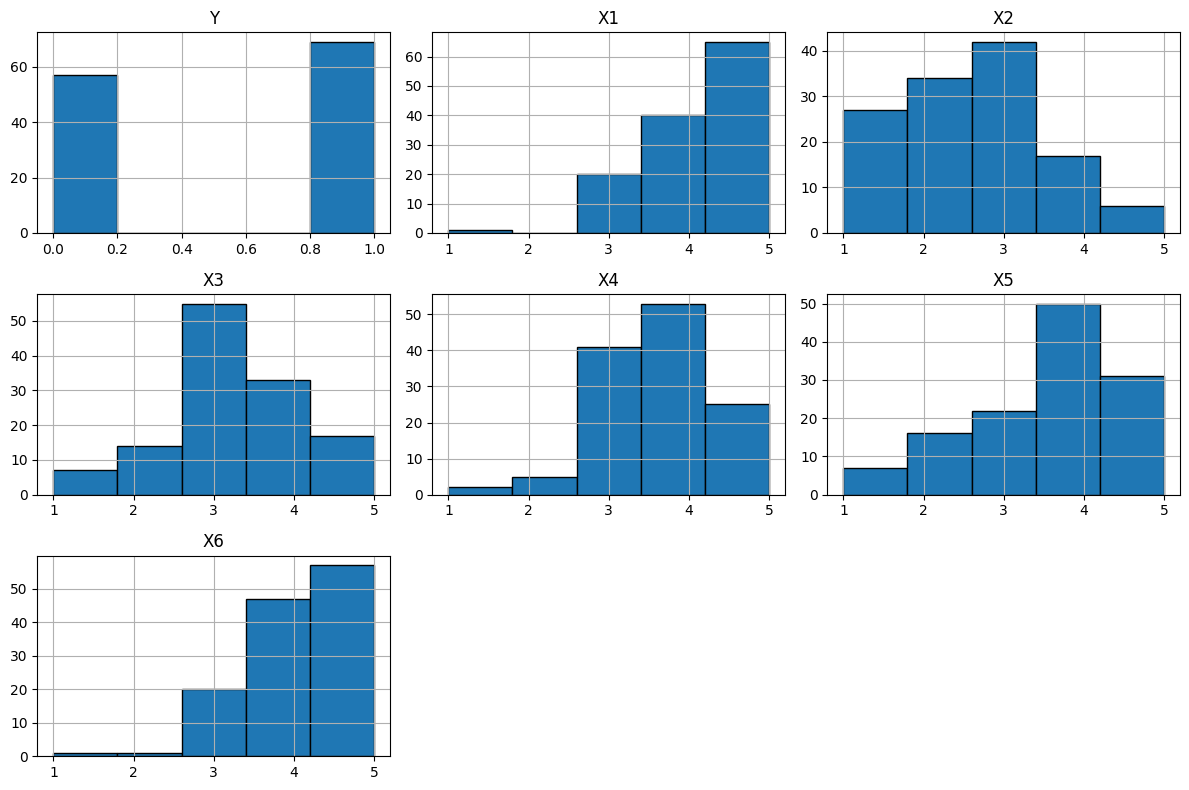

In [8]:
# Gridplot of histograms showing value distribution by column:

data.hist(figsize=(12, 8), bins=5, edgecolor='black')
plt.tight_layout()
plt.show()

- Data appears to be skewed towards 'positive' outcomes.
- Will need to use a stratified train-test split later on to conserve data distribution.

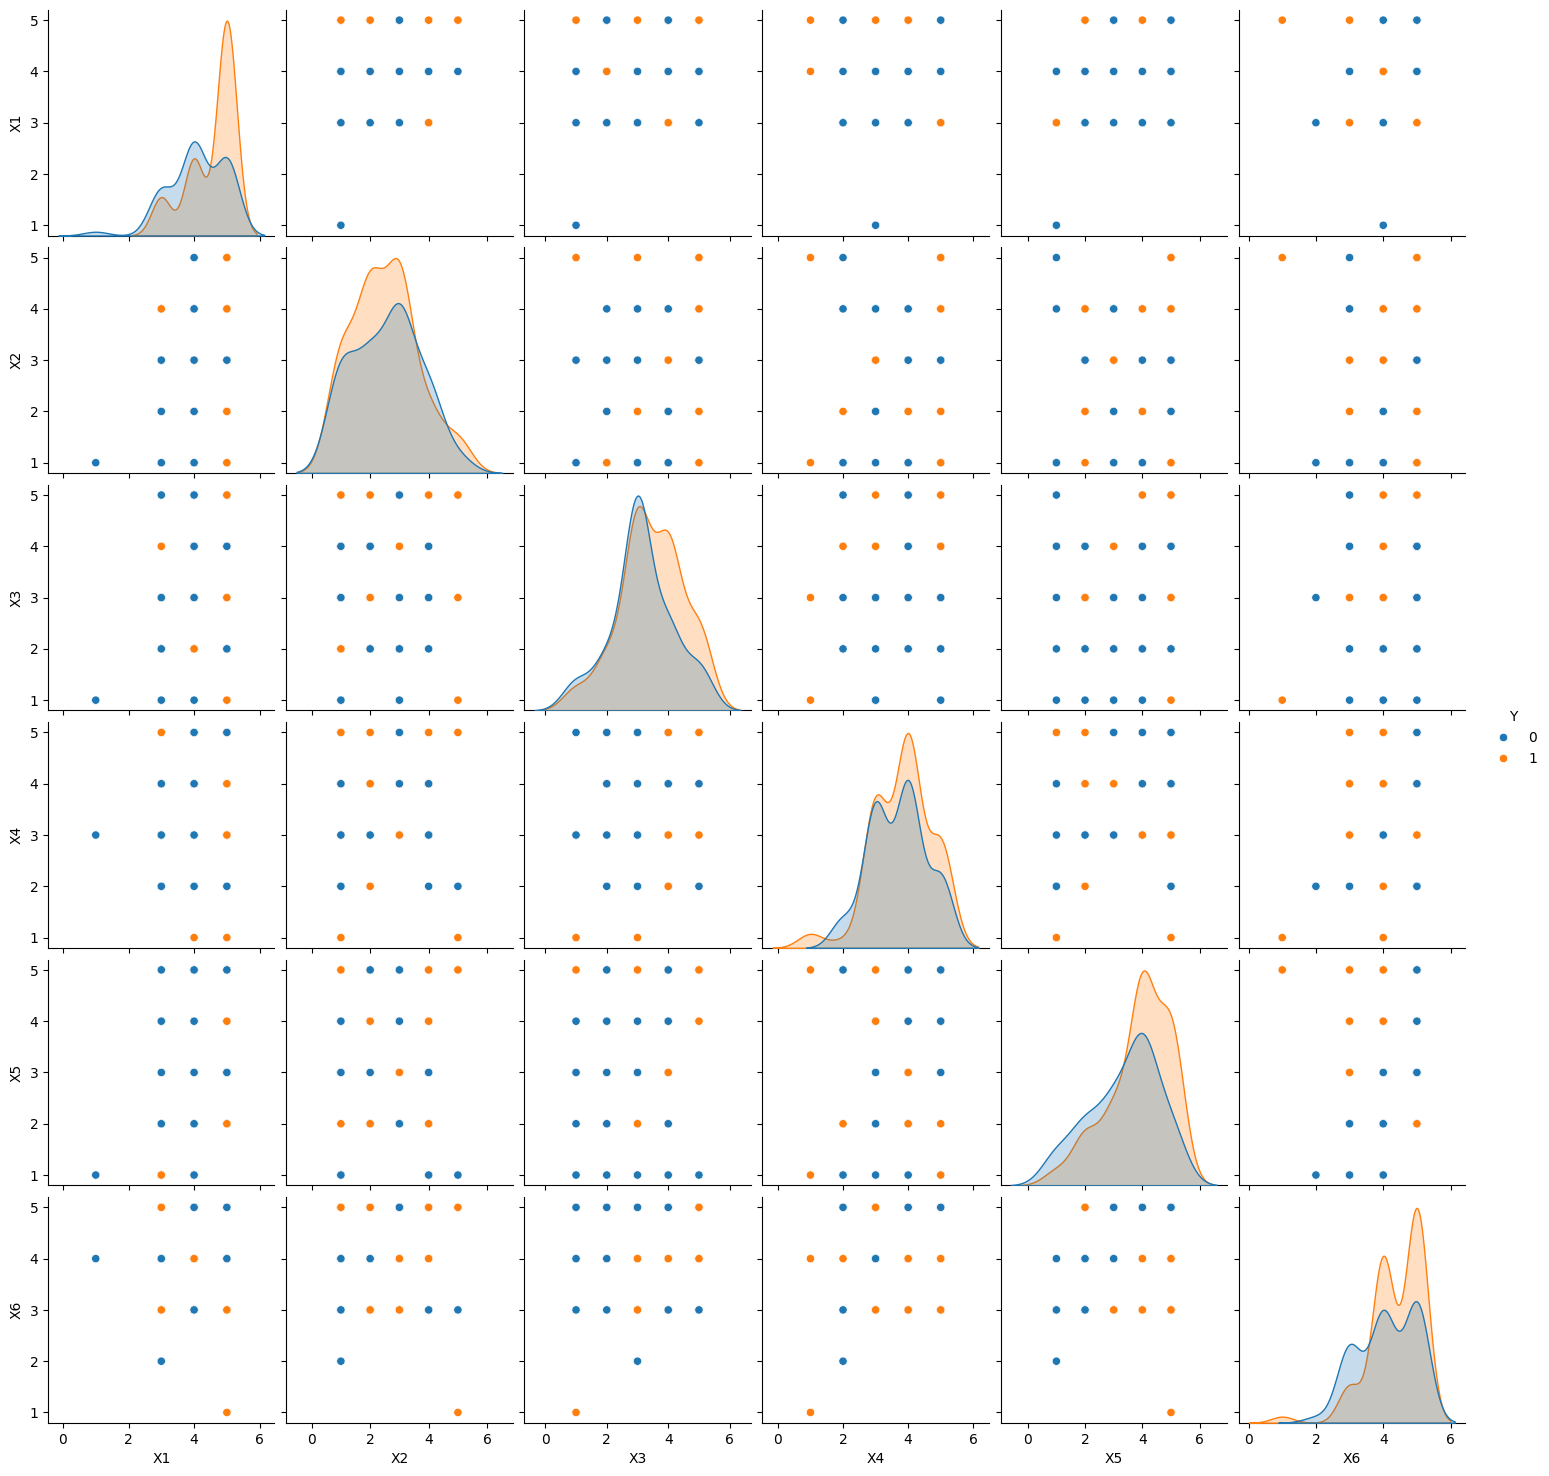

In [9]:
# Gridplot of scatter graphs for each possible pair of columns to show correlation (if any)
sns.pairplot(data, hue='Y', diag_kind='kde')

- Dificult to spot any visual correlation here. Will need to focus on numerical methods.

Outlier Detection

<Axes: >

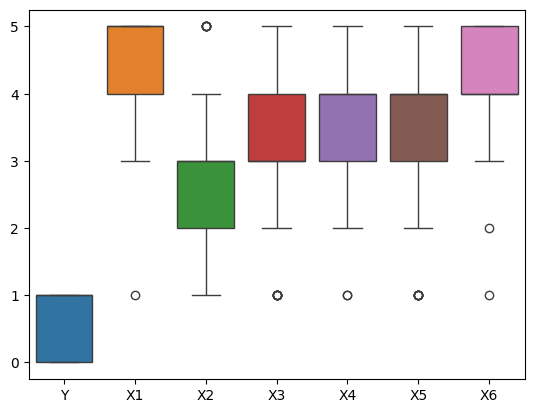

In [10]:
# General outlier detection:

sns.boxplot(data)

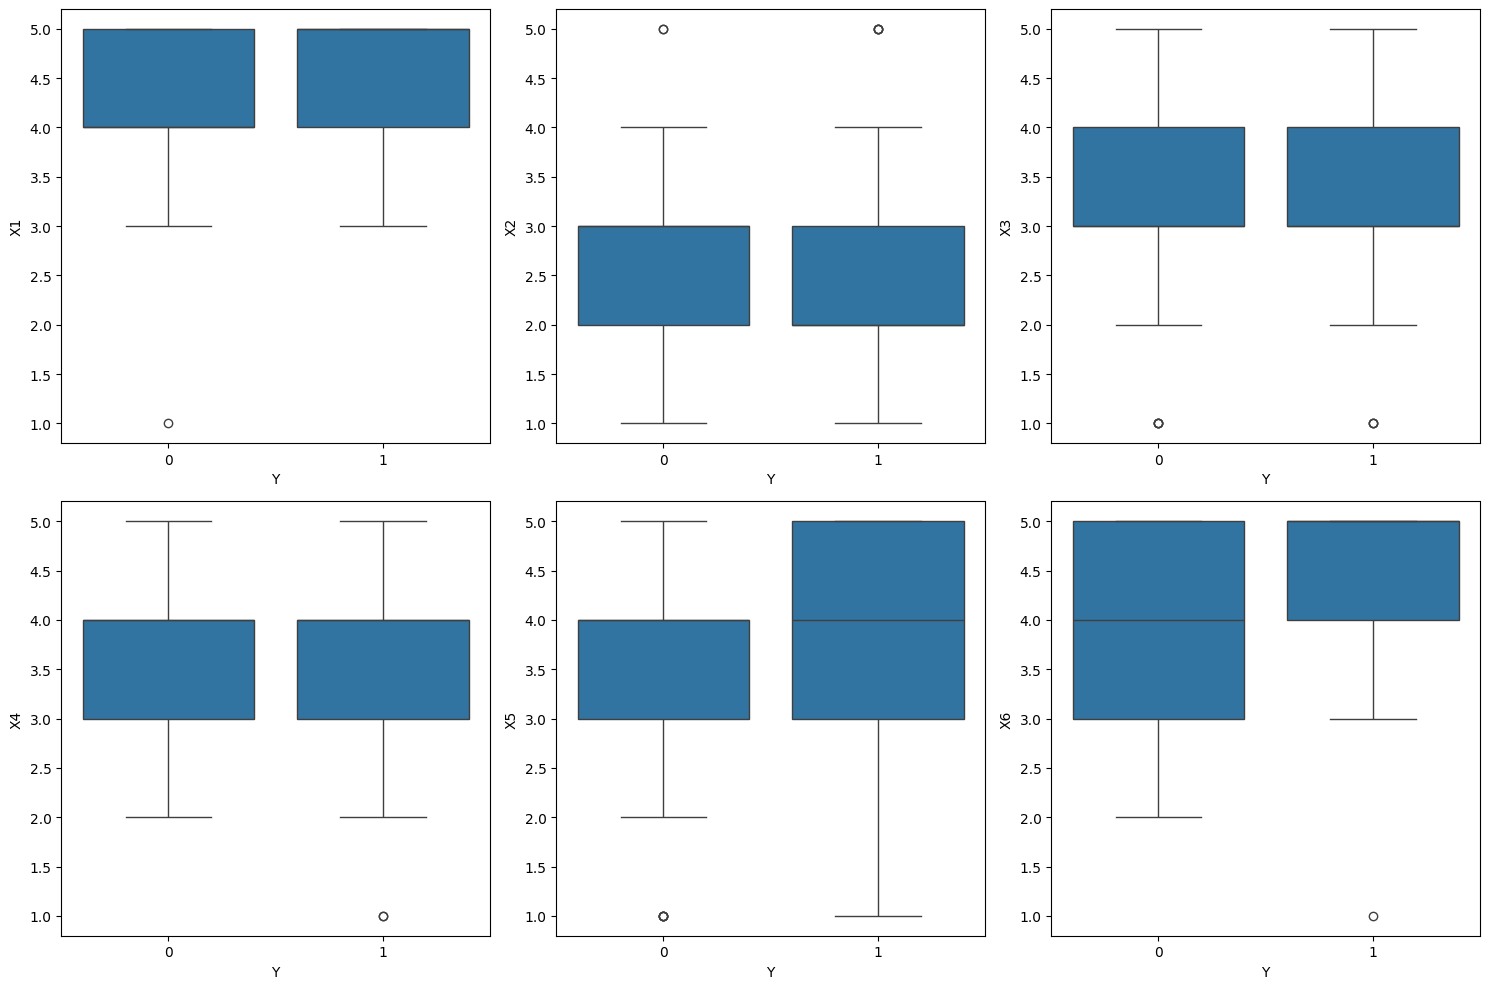

In [11]:
# Outlier detection by Y values:

feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    sns.boxplot(x='Y', y=feature, data=data, ax=axes[idx])
    axes[idx].set_xlabel('Y')
    axes[idx].set_ylabel(feature)

plt.tight_layout()
plt.show()

- Appears to be outliers present.
- May need to use robust scaling instead of standard scaling if we need to scale these numerical features.

<h4>Data Preparation (Splitting + Scaling)</h4>

- The dataset is small and simple.
- Binary classification model is needed.
- Will use a the simple 'LogisticRegression' in scikit-learn.
- Will treat X1-X6 as numerical columns, and Y as a categorical column (0 or 1).

In [12]:
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
target_cols = ['Y']

X = data[feature_cols]
Y = data[target_cols]

1. Train-test split:

- There aren't an equal number of 0 and 1 values in Y. We need to make sure that the training data captures this by specifying the 'stratify' kwarg in the sklearn splitting function.

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, stratify=Y["Y"], random_state=13
 )  # Preserve class balance in train/test splits.

Y_train = Y_train["Y"].to_numpy().ravel() # Ensure a 1d array is present for Y
Y_test = Y_test["Y"].to_numpy().ravel() # ""

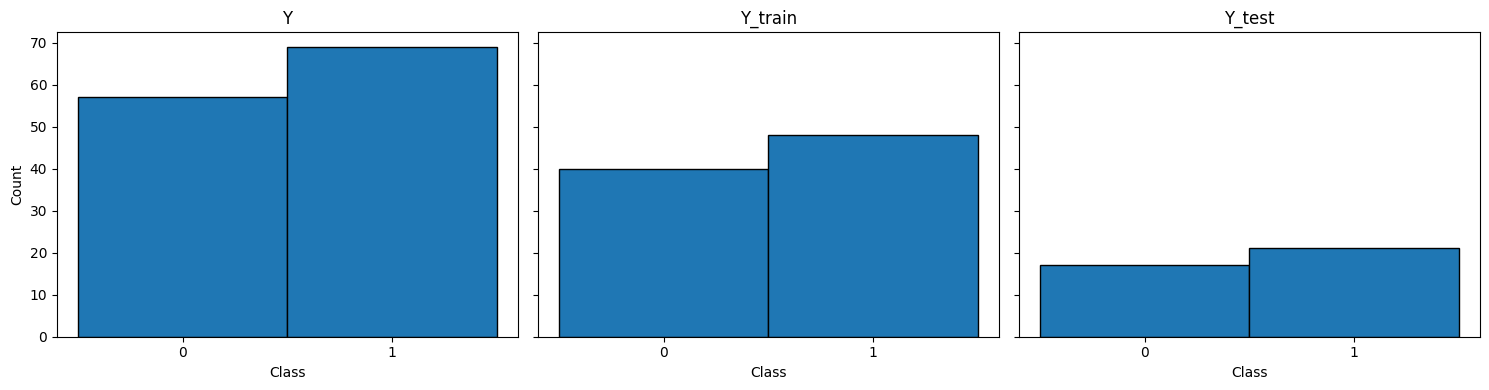

In [15]:
# Checking the value distribution of Y splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

datasets = [("Y", Y), ("Y_train", Y_train), ("Y_test", Y_test)]

for ax, (name, y_data) in zip(axes, datasets):
    if isinstance(y_data, pd.DataFrame):
        y_vals = y_data["Y"].to_numpy()
    elif isinstance(y_data, pd.Series):
        y_vals = y_data.to_numpy()
    else:
        y_vals = np.asarray(y_data).ravel()

    ax.hist(y_vals, bins=[-0.5, 0.5, 1.5], edgecolor="black")
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_xticks([0, 1])

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

2. Scaling

- Will use robust scaling here to deal with the outliers present

In [16]:
from sklearn.preprocessing import RobustScaler

In [17]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit scaler to training first, then transform both train and test X using the same scaler
X_test_scaled = scaler.transform(X_test)

- Not bothering to scale Y as false continuity may be introduced. This is something to avoid as this is a binary classification problem.

<h4>Model Training (sklearn LogisticRegression)</h4>

- Will start with a logistic regression model using sklearn

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
logr_model_1 = LogisticRegression(penalty="l2",          
                                C=1.0,                 
                                solver="lbfgs",        
                                max_iter=1000,         
                                random_state=13,
                                verbose=1,
                                class_weight="balanced")

In [20]:
# Train Model 1:
logr_model_1.fit(X_train_scaled,Y_train)
print(logr_model_1.n_iter_) #Actual number of iterations carried out

[10]


/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [21]:
# Predict off Model 1:
Y_pred_1 = logr_model_1.predict(X_test_scaled)
Y_proba_1 = logr_model_1.predict_proba(X_test_scaled)[:,1] # '1' label (positive class) probabilities for plotting ROC-AUC curve.

In [22]:
# Model 1 evaluation:
model_1_eval = evaluate_binary_classifier(Y_test,Y_pred_1,Y_proba_1)


===== Binary Classification Evaluation =====

Accuracy: 0.6053
Balanced Accuracy: 0.6092
Precision: 0.6667
Recall: 0.5714
F1 Score: 0.6154
Matthews Corrcoef: 0.2176
ROC AUC: 0.6303
Log Loss: 0.6818

Confusion Matrix:
[[11  6]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.67      0.57      0.62        21

    accuracy                           0.61        38
   macro avg       0.61      0.61      0.60        38
weighted avg       0.61      0.61      0.61        38



<h4>Feature Selection</h4>

- The initial model has an f1-score of 61% without feature selection. 
- Could spotting the most imapctful features improve this?

Feature Selection 1: 
- L1 regularisation during fitting (automatic feature selection)

In [23]:
logr_model_2 = LogisticRegression(penalty="l1",          
                                C=1.0,                 
                                solver="liblinear", #Can't use lbfgs with L1 regularisation  
                                max_iter=1000,         
                                random_state=13,
                                verbose=1,
                                class_weight="balanced")

logr_model_2.fit(X_train_scaled,Y_train)


Y_pred_2 = logr_model_2.predict(X_test_scaled)
Y_proba_2 = logr_model_2.predict_proba(X_test_scaled)[:,1]

model_2_eval = evaluate_binary_classifier(Y_test,Y_pred_2,Y_proba_2)

[LibLinear]iter   1  #CD cycles 1
iter   2  #CD cycles 4
iter   3  #CD cycles 1
iter   4  #CD cycles 1
iter   5  #CD cycles 1
iter   6  #CD cycles 4
iter   7  #CD cycles 1
iter   8  #CD cycles 2
iter   9  #CD cycles 1
iter  10  #CD cycles 2
iter  11  #CD cycles 1
iter  12  #CD cycles 2
optimization finished, #iter = 12
Objective value = 56.776660
#nonzeros/#features = 5/7

===== Binary Classification Evaluation =====

Accuracy: 0.6053
Balanced Accuracy: 0.6092
Precision: 0.6667
Recall: 0.5714
F1 Score: 0.6154
Matthews Corrcoef: 0.2176
ROC AUC: 0.6162
Log Loss: 0.6850

Confusion Matrix:
[[11  6]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.67      0.57      0.62        21

    accuracy                           0.61        38
   macro avg       0.61      0.61      0.60        38
weighted avg       0.61      0.61      0.61        38



/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


- Appears to be exactly the same

Feature Selection 2:
- Evaluate feature importance via different filtering metrics:

        - Correlation analysis (correlation matrix)
        - Variance threshold (sklearn VarianceThreshold)
        - Mutual information (sklearn mutual_info_classif)
        - ANOVA F-test (sklearn SelectKBest)

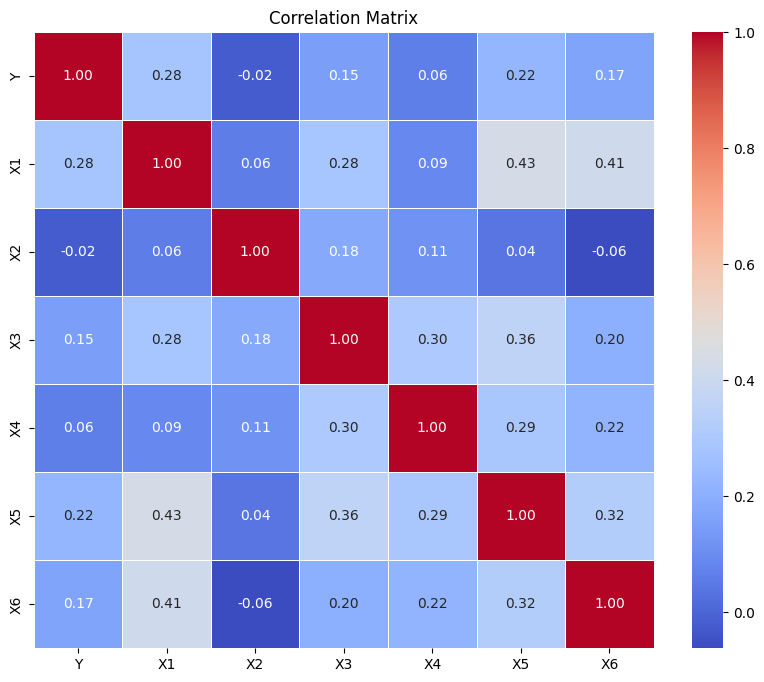

In [24]:
# 1. Correlation Analysis:

# Helps to identify correlation and multicolinearity

corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5
            )

plt.title("Correlation Matrix")
plt.show()

- There appears to be low correlation between features. The highest correlation exists between X1 and X5 (0.43).
- Higher values between X features would imply multicolinearity.
- Hard to identify redundant features here based on this technique alone.

In [25]:
# 2. Variance Theshold:

# Helps to identify features with little variability which doesn't provide much useful information.

from sklearn.feature_selection import VarianceThreshold

vt_selector = VarianceThreshold(threshold=0.01)

vt_selector.fit(X)

selected_v_features = X.columns[vt_selector.get_support()]
removed_v_features = X.columns[~vt_selector.get_support()]

print("Selected:")
print(selected_v_features)

print("\nRemoved:")
print(removed_v_features)


Selected:
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6'], dtype='str')

Removed:
Index([], dtype='str')


- All features appear to have some variance and therefore may contribute towards the outcome of Y

In [26]:
# 3. Mutual Information

from sklearn.feature_selection import mutual_info_classif

Y_array = Y["Y"].to_numpy().ravel() # Seems to complain when we pass a df column and not a 1d array for Y...

mi_scores = mutual_info_classif(X, Y_array)
print(mi_scores)

# Put MI scores into a sorted table with relative contribution (%)
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
}).sort_values("MI Score", ascending=False).reset_index(drop=True)

mi_total = mi_df["MI Score"].sum()
mi_df["Relative Importance (%)"] = (
    (mi_df["MI Score"] / mi_total * 100) if mi_total > 0 else 0
).round(2)

print(mi_df)

[0.0232394  0.         0.01970214 0.         0.04689707 0.        ]
  Feature  MI Score  Relative Importance (%)
0      X5  0.046897                    52.20
1      X1  0.023239                    25.87
2      X3  0.019702                    21.93
3      X2  0.000000                     0.00
4      X4  0.000000                     0.00
5      X6  0.000000                     0.00


- It may be worth training a model based on X1, X2 and X4 only?
- Will evaluate ANOVA F-test as a final test and then make a decision.

In [27]:
# 4. ANOVA F-test:

# Do the mean values of a feature differ significantly between the two target classes?

from sklearn.feature_selection import SelectKBest, f_classif

# Fit selector
af_selector = SelectKBest(score_func=f_classif, k="all")
af_selector.fit(X, Y_array)

# Create results dataframe
anova_results = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": af_selector.scores_,
    "P_Value": af_selector.pvalues_
})

# Sort by importance
anova_results = anova_results.sort_values(
    by="F_Score",
    ascending=False
)

print(anova_results)

  Feature    F_Score   P_Value
0      X1  10.561708  0.001486
4      X5   6.582716  0.011488
5      X6   3.586849  0.060568
2      X3   2.886959  0.091807
3      X4   0.516657  0.473623
1      X2   0.073108  0.787313


In [28]:
# Recap of mutual information scores:
print(mi_df)

  Feature  MI Score  Relative Importance (%)
0      X5  0.046897                    52.20
1      X1  0.023239                    25.87
2      X3  0.019702                    21.93
3      X2  0.000000                     0.00
4      X4  0.000000                     0.00
5      X6  0.000000                     0.00


- Variance threshold and correlation analyses didn't tell us much, so will make a decision based on mutual information (MI) and ANOVA F-scores.
- The strengths and weaknesses of these two metrics depend on if the data is linear or not. MI is good at detecting nonlinear relationships.
- ANOVA is better with logistic regression which is the problem we are tackling here.
- If a feature has a high MI score but a low ANOVA score, it is likely a non-linear feature and it would therefore be best to make a decision on it based on the MI score. This is the case for X2 and X4.
- The rest are likely linear meaning that the high ANOVA F-score would mean it is a useful feature. 
- Based on this, the overall features to include are X1, X2, X4 and X6. We would be getting rid of X5 and X3.
- Let's train a model based on this selection.

In [29]:
# Use 'fsc' in the variable names to denote 'feature selection combined' (We are using a combination of MI and ANOVA-F)

fsc_features = ['X1','X2','X4','X6']
X_fsc = X[fsc_features]

X_train_fsc, X_test_fsc, Y_train_fsc, Y_test_fsc = train_test_split(X_fsc, Y, test_size=0.3, stratify=Y["Y"], random_state=13)  

Y_train_fsc = Y_train_fsc["Y"].to_numpy().ravel() # Ensure a 1d array is present for Y
Y_test_fsc = Y_test_fsc["Y"].to_numpy().ravel() # ""

fsc_scaler = RobustScaler()
X_train_fsc_scaled = scaler.fit_transform(X_train_fsc) 
X_test_fsc_scaled = scaler.transform(X_test_fsc)

logr_model_fsc = LogisticRegression(penalty="l2",          
                                C=1.0,                 
                                solver="lbfgs",        
                                max_iter=1000,         
                                random_state=13,
                                verbose=1,
                                class_weight="balanced")


logr_model_fsc.fit(X_train_fsc_scaled,Y_train_fsc)

Y_pred_fsc = logr_model_fsc.predict(X_test_fsc_scaled)
Y_proba_fsc = logr_model_fsc.predict_proba(X_test_fsc_scaled)[:,1]

model_fsc_eval = evaluate_binary_classifier(Y_test_fsc,Y_pred_fsc,Y_proba_fsc)


===== Binary Classification Evaluation =====

Accuracy: 0.6053
Balanced Accuracy: 0.6092
Precision: 0.6667
Recall: 0.5714
F1 Score: 0.6154
Matthews Corrcoef: 0.2176
ROC AUC: 0.5980
Log Loss: 0.6891

Confusion Matrix:
[[11  6]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.67      0.57      0.62        21

    accuracy                           0.61        38
   macro avg       0.61      0.61      0.60        38
weighted avg       0.61      0.61      0.61        38



/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


- It's exactly the same?
- Whilst we haven't been able to improve model performance based on feature selection it shows that the two features we removed weren't contributing anything.

<h4>Misc</h4>

In [ ]:
# Training on a larger data set (0.8 train and 0.2 test):

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, stratify=Y["Y"], random_state=13
 )  # Preserve class balance in train/test splits.

Y_train = Y_train["Y"].to_numpy().ravel() # Ensure a 1d array is present for Y
Y_test = Y_test["Y"].to_numpy().ravel() # ""

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit scaler to training first, then transform both train and test X using the same scaler
X_test_scaled = scaler.transform(X_test)


logr_model_tl = LogisticRegression(penalty="l2",          
                                C=1.0,                 
                                solver="lbfgs",        
                                max_iter=1000,         
                                random_state=13,
                                verbose=1,
                                class_weight="balanced")

logr_model_tl.fit(X_train_scaled,Y_train)


Y_pred_tl = logr_model_tl.predict(X_test_scaled)
Y_proba_tl = logr_model_tl.predict_proba(X_test_scaled)[:,1]

model_tl_eval = evaluate_binary_classifier(Y_test,Y_pred_tl,Y_proba_tl)


===== Binary Classification Evaluation =====

Accuracy: 0.5385
Balanced Accuracy: 0.5357
Precision: 0.5714
Recall: 0.5714
F1 Score: 0.5714
Matthews Corrcoef: 0.0714
ROC AUC: 0.6071
Log Loss: 0.7230

Confusion Matrix:
[[6 6]
 [6 8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        12
           1       0.57      0.57      0.57        14

    accuracy                           0.54        26
   macro avg       0.54      0.54      0.54        26
weighted avg       0.54      0.54      0.54        26



/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


- F1-score has decerased?